# KAN Vision Transformer for Skin Lesion Classification

## 1. Setup and Imports

In [1]:
%pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'repr' attribute with value.*")
warnings.filterwarnings("ignore", message=".*The 'frozen' attribute with value.*")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
import timm
from kan import KAN
from tqdm import tqdm
import copy

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedxc4/skin-ds")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-ds


## 2. KAN ViT Implementation

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class KANLinear(nn.Module):
    """Linear layer with learnable B-spline activations on each edge."""
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        """Build the layers."""
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        """Initialize the base and spline weights."""
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(0, 1)  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result

    @property
    def scaled_spline_weight(self):
        """Return spline weights scaled by per-edge standardization."""
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        """Run the forward pass."""
        assert x.dim() == 2 and x.size(1) == self.in_features

        base_output = F.linear(self.base_activation(x), self.base_weight)
        
        # Efficient implementation of spline computation
        x_norm = (x - self.grid[0, 0]) / (self.grid[0, -1] - self.grid[0, 0]) * 2 - 1
        # Clamp to avoid out of range
        x_norm = torch.clamp(x_norm, -1 + self.grid_eps, 1 - self.grid_eps)
        
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        return base_output + spline_output


class EfficientKAN(nn.Module):
    """Stack of KANLinear layers used as a transformer feedforward."""
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        """Build the layers."""
        super(EfficientKAN, self).__init__()
        self.layers = nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                KANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_base=scale_base,
                    scale_spline=scale_spline,
                    base_activation=base_activation,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        """Run the forward pass."""
        for layer in self.layers:
            if update_grid:
                pass
            x = layer(x)
        return x



In [5]:
class KANViTBlock(nn.Module):
    """Transformer block with self-attention and a KAN or MLP feedforward."""
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        use_kan=True
    ):
        """Build the layers."""
        super().__init__()

        self.norm1 = norm_layer(dim)
        self.attn = timm.models.vision_transformer.Attention(
            dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop
        )

        self.drop_path = (
            timm.models.layers.DropPath(drop_path)
            if drop_path > 0.0 else nn.Identity()
        )

        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)

        if use_kan:
            self.mlp = EfficientKAN(
                layers_hidden=[dim, mlp_hidden_dim, dim],
                grid_size=5,
                spline_order=3
            )
        else:
            self.mlp = timm.models.layers.Mlp(
                in_features=dim,
                hidden_features=mlp_hidden_dim,
                act_layer=act_layer,
                drop=drop
            )

    def forward(self, x):
        """Run the forward pass."""
        x = x + self.drop_path(self.attn(self.norm1(x)))

        # Reshape for KAN (Batch, Tokens, Dim) -> (Batch * Tokens, Dim)
        B, N, C = x.shape
        x_reshaped = self.norm2(x).reshape(-1, C)
        x_kan = self.mlp(x_reshaped)
        x_kan = x_kan.reshape(B, N, C)

        x = x + self.drop_path(x_kan)
        return x


## 3. Model Creation

In [6]:
def create_kan_vit(model_name='vit_small_patch16_224', num_classes=7):
    # Load a pretrained ViT model from timm
    """Build an EfficientKANViT with the given depth, width, and heads."""
    vit_model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=num_classes,
        img_size=160
    )

    # FREEZE BACKBONE (Optimization)
    for param in vit_model.parameters():
        param.requires_grad = False
    # Unfreeze head
    if hasattr(vit_model, 'head'):
        for param in vit_model.head.parameters():
            param.requires_grad = True

    # Replace each block in the ViT with our KANViTBlock
    for i, block in enumerate(vit_model.blocks[:2]):  # Only replace first 2 blocks to save memory
        print(f"Replacing block {i}...") 
        # Extract parameters from the original block
        dim = block.attn.proj.in_features
        num_heads = block.attn.num_heads
        drop = block.attn.proj_drop.p
        attn_drop = block.attn.attn_drop.p

        # Check if drop_path exists and handle accordingly
        drop_path = 0.0
        if hasattr(block, 'drop_path') and hasattr(block.drop_path, 'drop_prob'):
            drop_path = block.drop_path.drop_prob

        # Create a new KANViTBlock
        kan_block = KANViTBlock(
            dim=dim,
            num_heads=num_heads,
            mlp_ratio=4.0, # Standard for ViT
            qkv_bias=True,
            drop=drop,
            attn_drop=attn_drop,
            drop_path=drop_path
        )

        # Copy weights from original block to the new block
        kan_block.norm1.load_state_dict(block.norm1.state_dict())
        kan_block.attn.load_state_dict(block.attn.state_dict())
        kan_block.norm2.load_state_dict(block.norm2.state_dict())
        # The MLP layer is now a KAN, so we don't copy its weights

        vit_model.blocks[i] = kan_block
        # Cleanup memory
        import gc
        del block
        gc.collect()
        torch.cuda.empty_cache()


    return vit_model

# Create the model
num_classes = 14
kan_vit_model = create_kan_vit(num_classes=num_classes)

# Print model summary
summary(kan_vit_model, input_size=(1, 3, 160, 160))


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Replacing block 0...
Replacing block 1...


Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [1, 14]                   39,168
├─PatchEmbed: 1-1                        [1, 100, 384]             --
│    └─Conv2d: 2-1                       [1, 384, 10, 10]          (295,296)
│    └─Identity: 2-2                     [1, 100, 384]             --
├─Dropout: 1-2                           [1, 101, 384]             --
├─Identity: 1-3                          [1, 101, 384]             --
├─Identity: 1-4                          [1, 101, 384]             --
├─Sequential: 1-5                        [1, 101, 384]             --
│    └─KANViTBlock: 2-3                  [1, 101, 384]             --
│    │    └─LayerNorm: 3-1               [1, 101, 384]             768
│    │    └─Attention: 3-2               [1, 101, 384]             591,360
│    │    └─Identity: 3-3                [1, 101, 384]             --
│    │    └─LayerNorm: 3-4               [1, 101, 384]             7

## 4. Data Loading and Preprocessing

In [7]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(160),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    'val': transforms.Compose([
        transforms.Resize(180),
        transforms.CenterCrop(160),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

data_dir = '/kaggle/input/skin-ds/' # Path for the Kaggle environment

image_datasets = {
    x: datasets.ImageFolder(
        root=f"{data_dir}/{x}",
        transform=data_transforms[x]
    )
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=32,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Training size:", dataset_sizes['train'])
print("Validation size:", dataset_sizes['val'])

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 14
Training size: 29322
Validation size: 3660


## 5. Training the Model

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = kan_vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 25

def train_model(model, criterion, optimizer, num_epochs):
    """Train the model, log per-epoch metrics, and keep the best checkpoint."""
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train':
                        with torch.cuda.amp.autocast():
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model

In [8]:
model_ft = train_model(model, criterion, optimizer, num_epochs)

/tmp/ipykernel_47/1478036455.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_47/1478036455.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [05:51<00:00,  2.61it/s]


train Loss: 1.4638 Acc: 0.5087


100%|██████████| 115/115 [00:22<00:00,  5.11it/s]


...

val Loss: 0.6099 Acc: 0.7732
Epoch 24/24
----------


100%|██████████| 917/917 [05:53<00:00,  2.59it/s]


train Loss: 0.6413 Acc: 0.7665


100%|██████████| 115/115 [00:22<00:00,  5.20it/s]

val Loss: 0.6094 Acc: 0.7885
Best val Acc: 0.7885


## 6. Save the Model

In [16]:
torch.save(model_ft.state_dict(), 'kan_vit_skin_lesion_25_epochs.pth')
print('save successful')

save successful


## 7. Continue Training

In [18]:
# Load the model from previous training
saved_model_path = '/kaggle/input/m/deettoh/kan-vit-skin-lesion-25-epochs/pytorch/default/1/kan_vit_skin_lesion_25_epochs.pth'

# Load the weights
print(f"Loading weights from {saved_model_path}...")
# Use map_location to handle potential cpu/gpu mismatch if needed, but usually safe to load
try:
    model.load_state_dict(torch.load(saved_model_path))
except FileNotFoundError:
    print("Warning: Specific path not found, trying local path 'kan_vit_skin_lesion.pth'...")
    model.load_state_dict(torch.load('kan_vit_skin_lesion.pth'))

# Continue training for 5 more epochs
# We reduce the learning rate slightly for fine-tuning
optimizer_ft = optim.AdamW(model.parameters(), lr=1e-5)

print("Continuing training for 5 more epochs...")
model_ft = train_model(model, criterion, optimizer_ft, num_epochs=5)

/tmp/ipykernel_47/1089644434.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Loading weights from /kaggle/input/m/deettoh/kan-vit-skin-lesion-25-epochs/pytorch/default/1/kan_vit_skin_lesion_25_epochs.pth...
Continuing training for 5 more epochs...
Epoch 0/4
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_47/1089644434.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [05:54<00:00,  2.59it/s]


train Loss: 0.5916 Acc: 0.7861


100%|██████████| 115/115 [00:23<00:00,  4.85it/s]


...

val Loss: 0.5518 Acc: 0.8003
Epoch 4/4
----------


100%|██████████| 917/917 [05:53<00:00,  2.59it/s]


train Loss: 0.5543 Acc: 0.7997


100%|██████████| 115/115 [00:23<00:00,  4.96it/s]


val Loss: 0.5498 Acc: 0.8003
Best val Acc: 0.8003


In [19]:
# Save the extended model
torch.save(model_ft.state_dict(), 'kan_vit_skin_lesion_30_epochs.pth')
print('model saved')

model saved


## 7. Evaluation & Visualization

In [10]:
# === Load Pure KAN-ViT Model ===
checkpoint_path = '/kaggle/input/kanvit2/pytorch/default/1/kan_vit_skin_lesion_30_epochs.pth'  # Update path as needed

print(f"Loading Pure KAN-ViT from {checkpoint_path}...")

# Create model with correct config (uses timm ViT as base)
loaded_model = create_kan_vit(
    model_name='vit_small_patch16_224',
    num_classes=14
)

# Load weights
checkpoint = torch.load(checkpoint_path, map_location=device)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
else:
    loaded_model.load_state_dict(checkpoint)

loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Pure KAN-ViT loaded successfully!")

Loading Pure KAN-ViT from /kaggle/input/kanvit2/pytorch/default/1/kan_vit_skin_lesion_30_epochs.pth...
Replacing block 0...
Replacing block 1...
Pure KAN-ViT loaded successfully!


ROC-AUC Curve Analysis
Computing predictions for ROC-AUC...


100%|██████████| 115/115 [00:17<00:00,  6.74it/s]



AUC Scores by Class:
  Actinic keratoses                  : 0.9690
  Basal cell carcinoma               : 0.9771
  Benign keratosis-like lesions      : 0.9228
  Chickenpox                         : 0.9952
  Cowpox                             : 0.9998
  Dermatofibroma                     : 0.9833
  HFMD                               : 0.9986
  Healthy                            : 0.9995
  Measles                            : 0.9987
  Melanocytic nevi                   : 0.9654
  Melanoma                           : 0.9212
  Monkeypox                          : 0.9981
  Squamous cell carcinoma            : 0.9593
  Vascular lesions                   : 0.9987
--------------------------------------------------
  Micro-average                      : 0.9882
  Macro-average                      : 0.9776


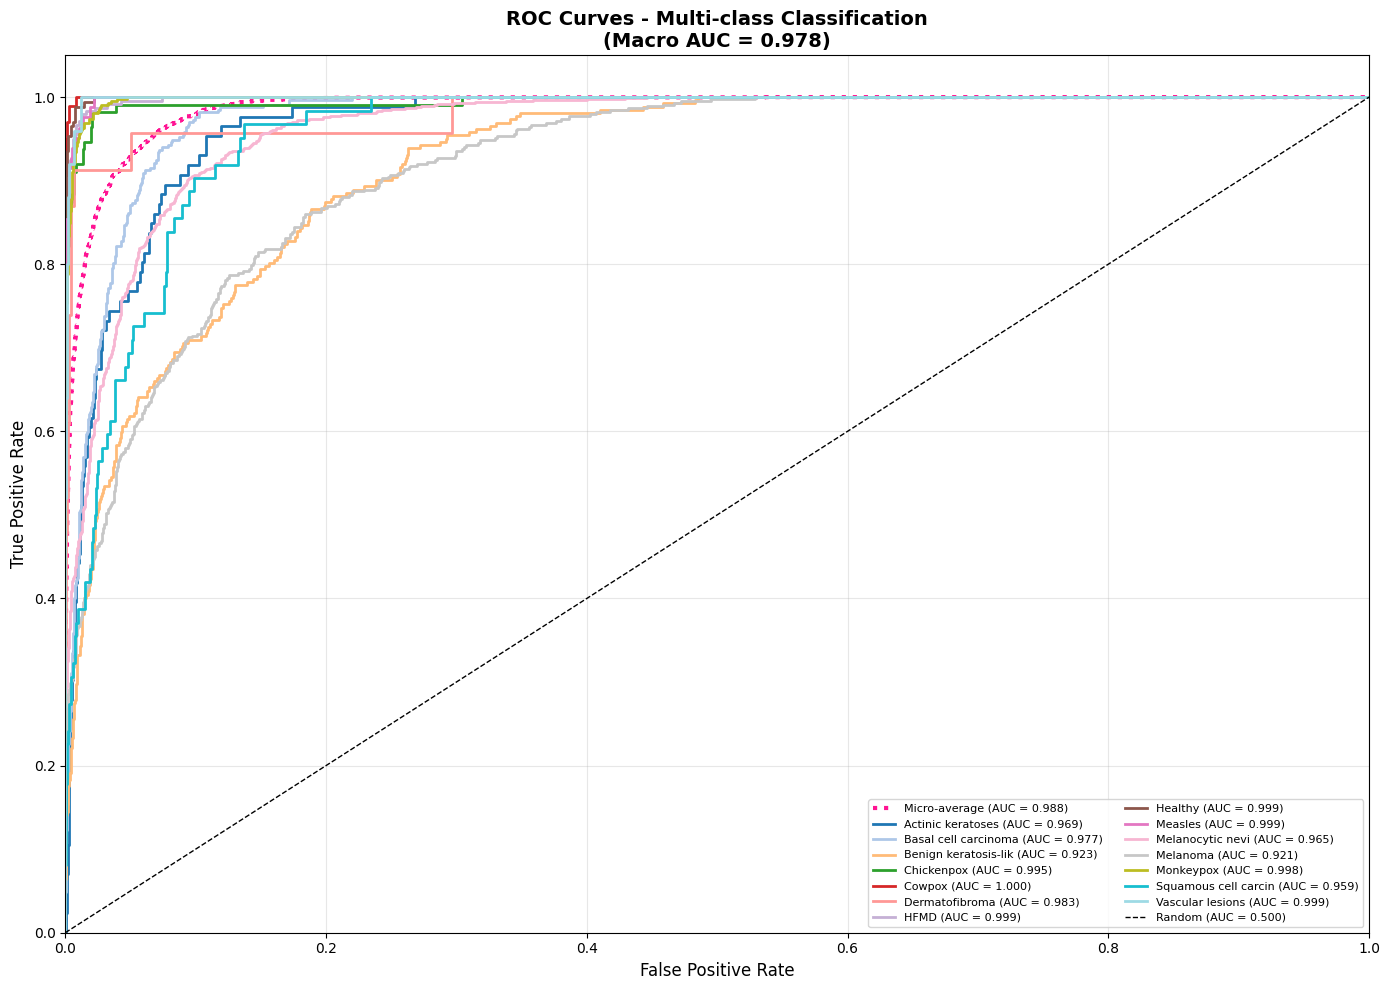


Saved to 'roc_auc_curves.png'


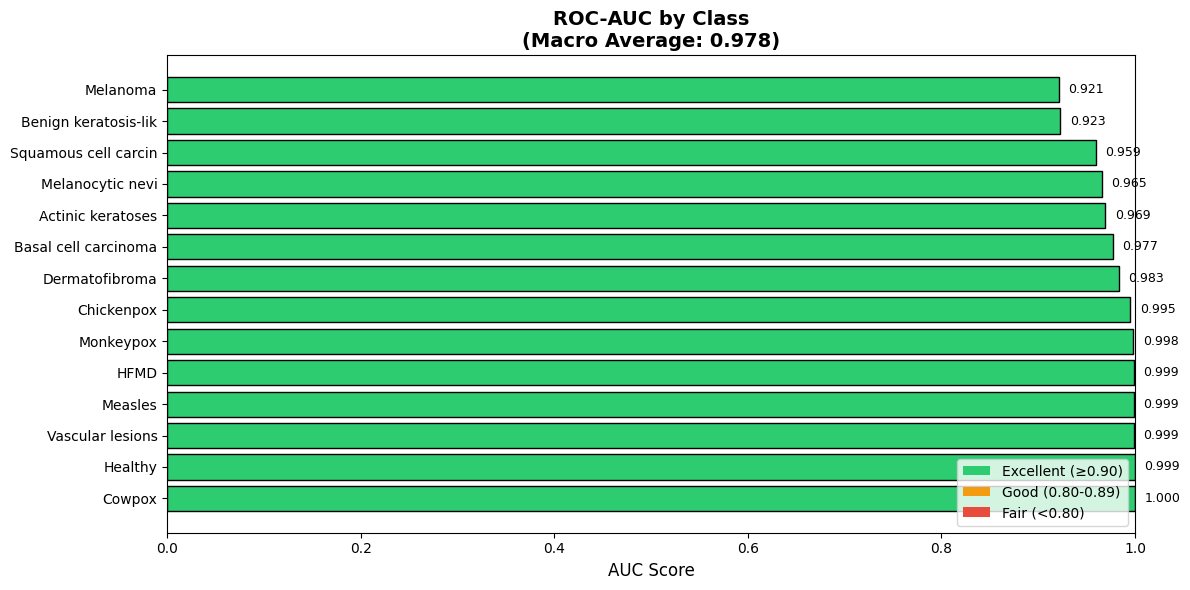


Saved to 'roc_auc_summary.png'


In [11]:
# === ROC-AUC Curve Generation ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from itertools import cycle

def compute_roc_auc(model, dataloader, class_names, device):
    """
    Compute ROC-AUC for multi-class classification.
    
    Returns:
        all_labels: True labels
        all_probs: Predicted probabilities for each class
        fpr: False positive rates (dict per class)
        tpr: True positive rates (dict per class)
        roc_auc: AUC scores (dict per class)
    """
    model.eval()
    all_labels = []
    all_probs = []
    
    print("Computing predictions for ROC-AUC...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(class_names)
    
    # Binarize labels for multi-class ROC
    labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    
    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average AUC
    roc_auc["macro"] = np.mean([roc_auc[i] for i in range(n_classes)])
    
    return all_labels, all_probs, fpr, tpr, roc_auc


def plot_roc_curves(fpr, tpr, roc_auc, class_names, figsize=(14, 10)):
    """
    Plot ROC curves for all classes.
    """
    n_classes = len(class_names)
    
    # Colors for each class
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    plt.figure(figsize=figsize)
    
    # Plot micro-average ROC curve
    plt.plot(
        fpr["micro"], tpr["micro"],
        label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
        color='deeppink', linestyle=':', linewidth=3
    )
    
    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.plot(
            fpr[i], tpr[i], color=color, lw=2,
            label=f'{class_name[:20]} (AUC = {roc_auc[i]:.3f})'
        )
    
    # Diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - Multi-class Classification\n(Macro AUC = {roc_auc["macro"]:.3f})', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_auc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'roc_auc_curves.png'")
    return


def plot_roc_summary(roc_auc, class_names, figsize=(12, 6)):
    """
    Plot a bar chart showing AUC scores for each class.
    """
    n_classes = len(class_names)
    aucs = [roc_auc[i] for i in range(n_classes)]
    
    # Sort by AUC
    sorted_indices = np.argsort(aucs)[::-1]
    sorted_names = [class_names[i][:20] for i in sorted_indices]
    sorted_aucs = [aucs[i] for i in sorted_indices]
    
    # Colors based on AUC
    colors = ['#2ecc71' if a >= 0.9 else '#f39c12' if a >= 0.8 else '#e74c3c' for a in sorted_aucs]
    
    plt.figure(figsize=figsize)
    bars = plt.barh(range(n_classes), sorted_aucs, color=colors, edgecolor='black')
    plt.yticks(range(n_classes), sorted_names, fontsize=10)
    plt.xlabel('AUC Score', fontsize=12)
    plt.title(f'ROC-AUC by Class\n(Macro Average: {roc_auc["macro"]:.3f})', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add value labels
    for i, (bar, auc_val) in enumerate(zip(bars, sorted_aucs)):
        plt.text(auc_val + 0.01, i, f'{auc_val:.3f}', va='center', fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Excellent (≥0.90)'),
        Patch(facecolor='#f39c12', label='Good (0.80-0.89)'),
        Patch(facecolor='#e74c3c', label='Fair (<0.80)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('roc_auc_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'roc_auc_summary.png'")


# === RUN ===
print("="*60)
print("ROC-AUC Curve Analysis")
print("="*60)

# Compute ROC-AUC
all_labels, all_probs, fpr, tpr, roc_auc = compute_roc_auc(
    loaded_model, dataloaders['val'], class_names, device
)

# Print AUC scores
print("\n" + "="*50)
print("AUC Scores by Class:")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {roc_auc[i]:.4f}")
print("-"*50)
print(f"  {'Micro-average':35s}: {roc_auc['micro']:.4f}")
print(f"  {'Macro-average':35s}: {roc_auc['macro']:.4f}")
print("="*50)

# Plot ROC curves
plot_roc_curves(fpr, tpr, roc_auc, class_names)

# Plot summary bar chart
plot_roc_summary(roc_auc, class_names)

Precision-Recall Curve Analysis
Computing predictions for PR curves...


100%|██████████| 115/115 [00:17<00:00,  6.76it/s]



Average Precision (AP) Scores by Class:
  Actinic keratoses                  : 0.4312
  Basal cell carcinoma               : 0.7838
  Benign keratosis-like lesions      : 0.5733
  Chickenpox                         : 0.9421
  Cowpox                             : 0.9920
  Dermatofibroma                     : 0.7119
  HFMD                               : 0.9845
  Healthy                            : 0.9909
  Measles                            : 0.9593
  Melanocytic nevi                   : 0.9348
  Melanoma                           : 0.6903
  Monkeypox                          : 0.9857
  Squamous cell carcinoma            : 0.4046
  Vascular lesions                   : 0.8801
--------------------------------------------------
  Micro-average                      : 0.8917
  Macro-average                      : 0.8046


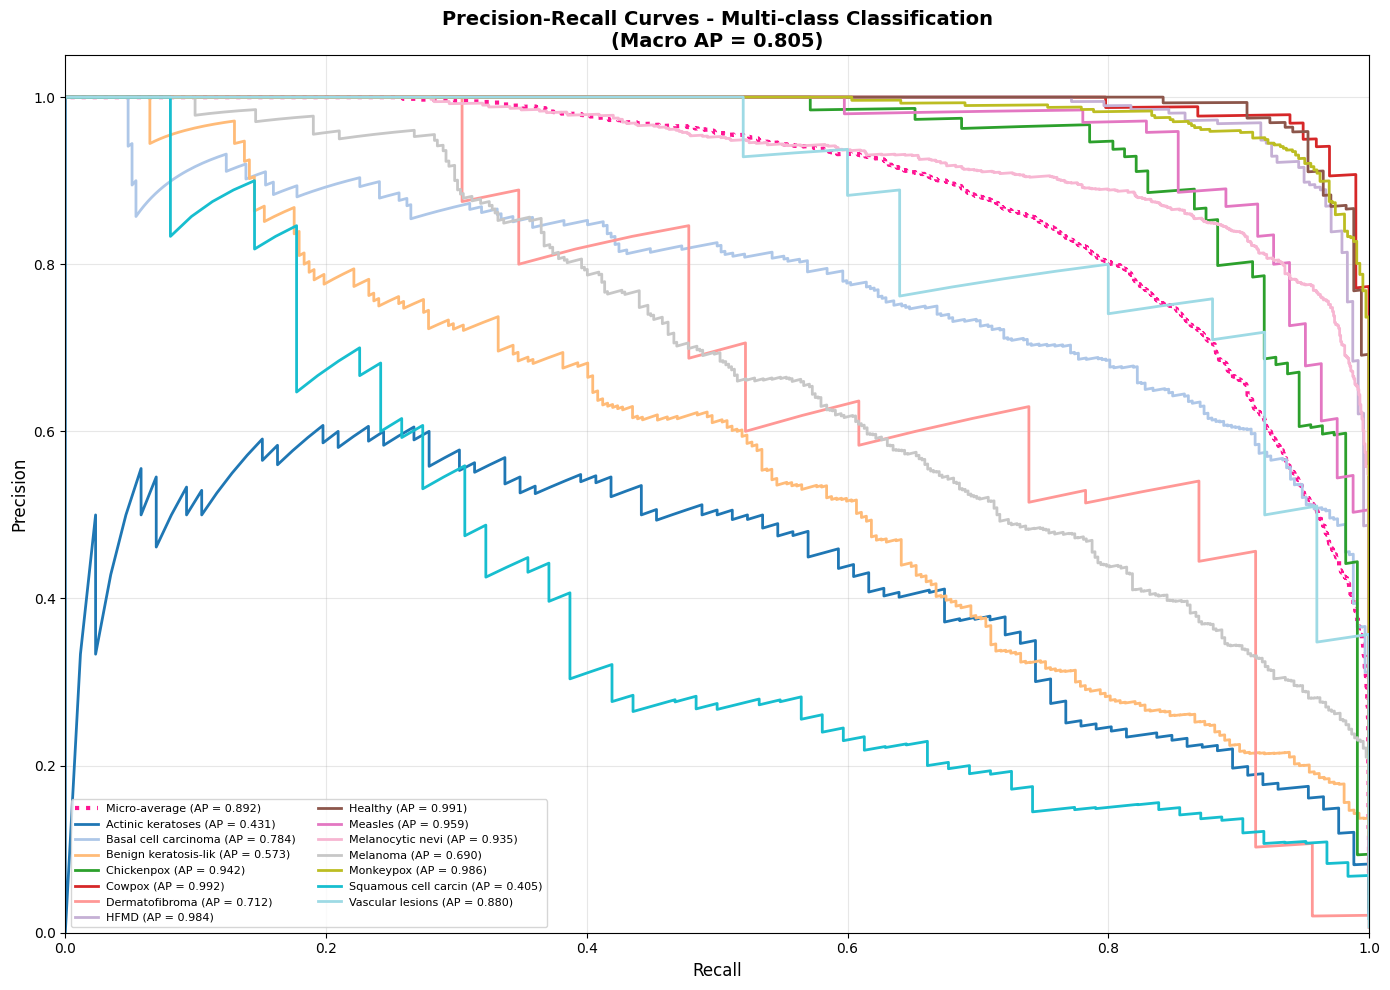


Saved to 'precision_recall_curves.png'


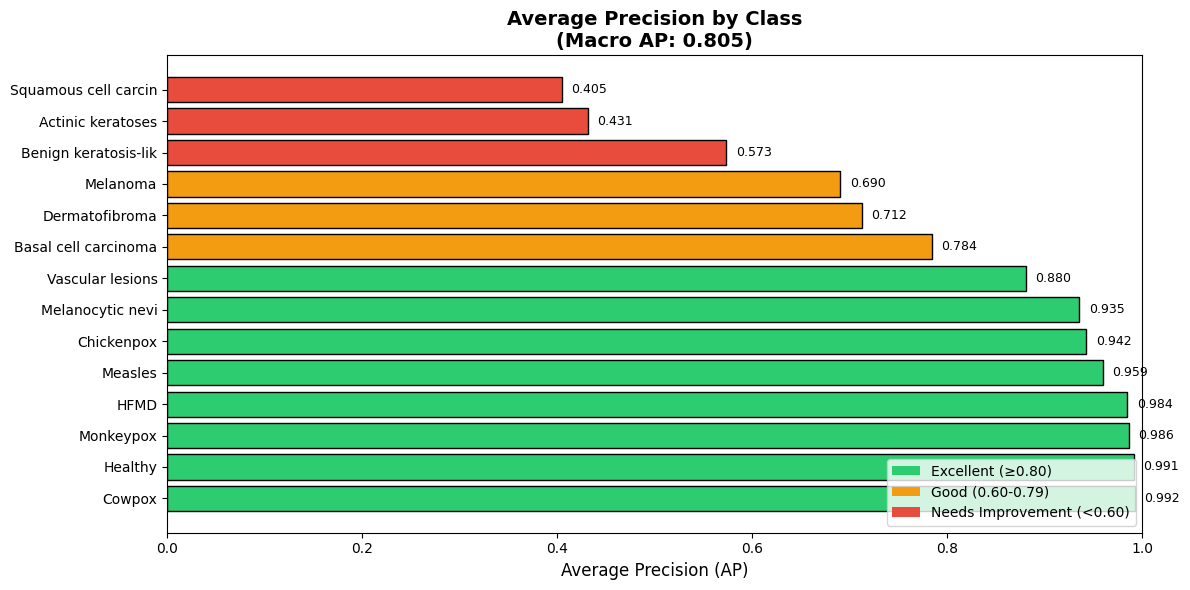


Saved to 'average_precision_summary.png'


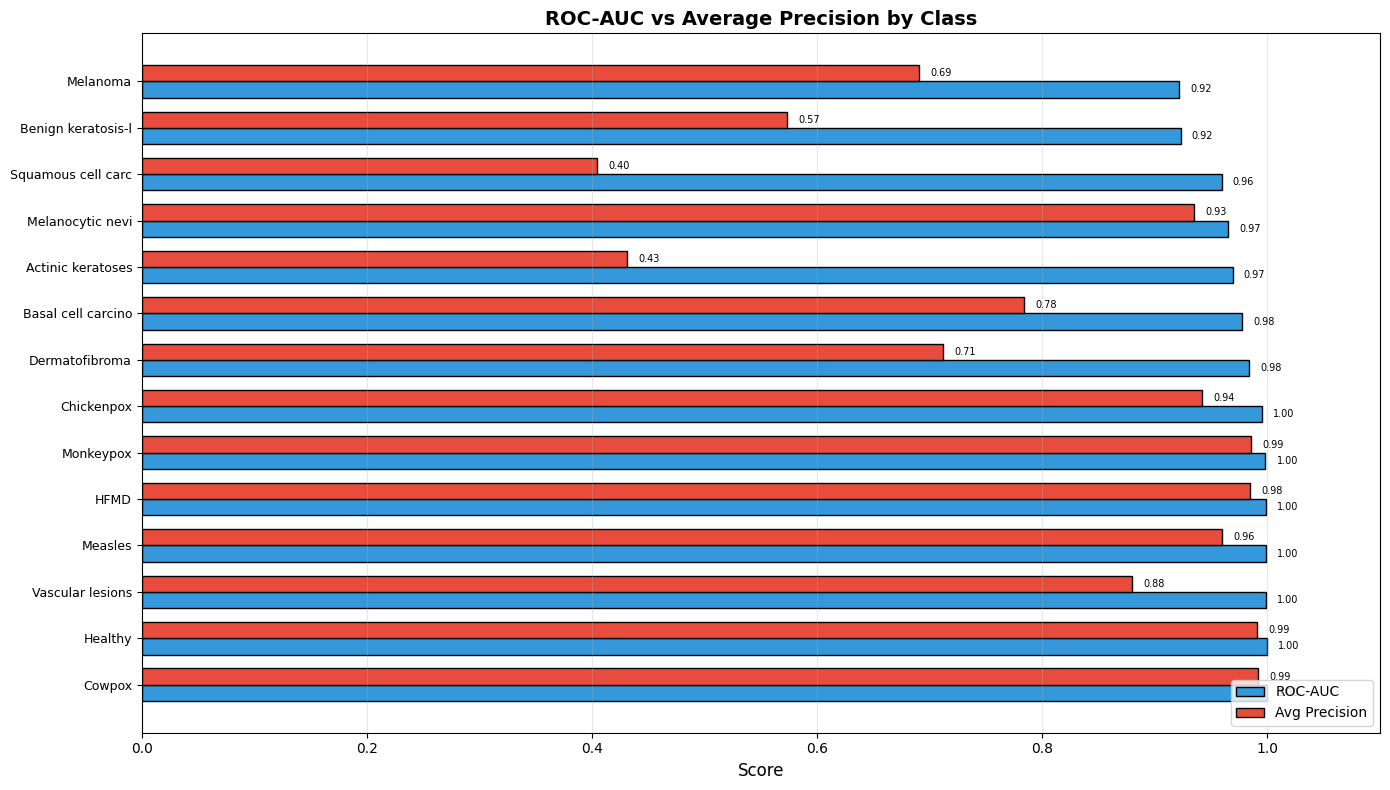


Saved to 'combined_metrics.png'


In [12]:
# === Precision-Recall Curve Generation ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

def compute_pr_curves(model, dataloader, class_names, device):
    """
    Compute Precision-Recall curves for multi-class classification.
    
    Returns:
        all_labels: True labels
        all_probs: Predicted probabilities for each class
        precision: Precision values (dict per class)
        recall: Recall values (dict per class)
        avg_precision: Average precision scores (dict per class)
    """
    model.eval()
    all_labels = []
    all_probs = []
    
    print("Computing predictions for PR curves...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(class_names)
    
    # Binarize labels for multi-class PR
    labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    
    # Compute PR curve and Average Precision for each class
    precision = {}
    recall = {}
    avg_precision = {}
    
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(labels_bin[:, i], all_probs[:, i])
        avg_precision[i] = average_precision_score(labels_bin[:, i], all_probs[:, i])
    
    # Compute micro-average PR curve
    precision["micro"], recall["micro"], _ = precision_recall_curve(
        labels_bin.ravel(), all_probs.ravel()
    )
    avg_precision["micro"] = average_precision_score(labels_bin, all_probs, average="micro")
    
    # Compute macro-average AP
    avg_precision["macro"] = np.mean([avg_precision[i] for i in range(n_classes)])
    
    return all_labels, all_probs, precision, recall, avg_precision


def plot_pr_curves(precision, recall, avg_precision, class_names, figsize=(14, 10)):
    """
    Plot Precision-Recall curves for all classes.
    """
    n_classes = len(class_names)
    
    # Colors for each class
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    plt.figure(figsize=figsize)
    
    # Plot micro-average PR curve
    plt.plot(
        recall["micro"], precision["micro"],
        label=f'Micro-average (AP = {avg_precision["micro"]:.3f})',
        color='deeppink', linestyle=':', linewidth=3
    )
    
    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.plot(
            recall[i], precision[i], color=color, lw=2,
            label=f'{class_name[:20]} (AP = {avg_precision[i]:.3f})'
        )
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curves - Multi-class Classification\n(Macro AP = {avg_precision["macro"]:.3f})', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'precision_recall_curves.png'")
    return


def plot_ap_summary(avg_precision, class_names, figsize=(12, 6)):
    """
    Plot a bar chart showing Average Precision scores for each class.
    """
    n_classes = len(class_names)
    aps = [avg_precision[i] for i in range(n_classes)]
    
    # Sort by AP
    sorted_indices = np.argsort(aps)[::-1]
    sorted_names = [class_names[i][:20] for i in sorted_indices]
    sorted_aps = [aps[i] for i in sorted_indices]
    
    # Colors based on AP
    colors = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.6 else '#e74c3c' for a in sorted_aps]
    
    plt.figure(figsize=figsize)
    bars = plt.barh(range(n_classes), sorted_aps, color=colors, edgecolor='black')
    plt.yticks(range(n_classes), sorted_names, fontsize=10)
    plt.xlabel('Average Precision (AP)', fontsize=12)
    plt.title(f'Average Precision by Class\n(Macro AP: {avg_precision["macro"]:.3f})', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add value labels
    for i, (bar, ap_val) in enumerate(zip(bars, sorted_aps)):
        plt.text(ap_val + 0.01, i, f'{ap_val:.3f}', va='center', fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Excellent (≥0.80)'),
        Patch(facecolor='#f39c12', label='Good (0.60-0.79)'),
        Patch(facecolor='#e74c3c', label='Needs Improvement (<0.60)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('average_precision_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'average_precision_summary.png'")


def plot_combined_metrics(roc_auc, avg_precision, class_names, figsize=(14, 8)):
    """
    Plot combined ROC-AUC and Average Precision comparison.
    """
    n_classes = len(class_names)
    
    x = np.arange(n_classes)
    width = 0.35
    
    aucs = [roc_auc[i] for i in range(n_classes)]
    aps = [avg_precision[i] for i in range(n_classes)]
    
    # Sort by AUC
    sorted_indices = np.argsort(aucs)[::-1]
    sorted_names = [class_names[i][:18] for i in sorted_indices]
    sorted_aucs = [aucs[i] for i in sorted_indices]
    sorted_aps = [aps[i] for i in sorted_indices]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars1 = ax.barh(x - width/2, sorted_aucs, width, label='ROC-AUC', color='#3498db', edgecolor='black')
    bars2 = ax.barh(x + width/2, sorted_aps, width, label='Avg Precision', color='#e74c3c', edgecolor='black')
    
    ax.set_xlabel('Score', fontsize=12)
    ax.set_title('ROC-AUC vs Average Precision by Class', fontsize=14, fontweight='bold')
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.set_xlim([0, 1.1])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, val in zip(bars1, sorted_aucs):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7)
    for bar, val in zip(bars2, sorted_aps):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.savefig('combined_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'combined_metrics.png'")


# === RUN ===
print("="*60)
print("Precision-Recall Curve Analysis")
print("="*60)

# Compute PR curves
all_labels, all_probs, precision, recall, avg_precision = compute_pr_curves(
    loaded_model, dataloaders['val'], class_names, device
)

# Print AP scores
print("\n" + "="*50)
print("Average Precision (AP) Scores by Class:")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {avg_precision[i]:.4f}")
print("-"*50)
print(f"  {'Micro-average':35s}: {avg_precision['micro']:.4f}")
print(f"  {'Macro-average':35s}: {avg_precision['macro']:.4f}")
print("="*50)

# Plot PR curves
plot_pr_curves(precision, recall, avg_precision, class_names)

# Plot AP summary bar chart
plot_ap_summary(avg_precision, class_names)

# If you have roc_auc from previous cell, plot combined comparison
try:
    plot_combined_metrics(roc_auc, avg_precision, class_names)
except NameError:
    print("\nNote: Run ROC-AUC cell first to generate combined metrics plot.")

FULL PERFORMANCE METRICS REPORT (with TTA)
Computing predictions with TTA (Original + HFlip + VFlip)...


100%|██████████| 115/115 [00:34<00:00,  3.37it/s]



OVERALL PERFORMANCE METRICS (with TTA)

Metric                                Value
---------------------------------------------
Accuracy (TTA)                       0.7962
Balanced Accuracy (TTA)              0.6914
Top-3 Accuracy (TTA)                 0.9705
Top-5 Accuracy (TTA)                 0.9954
Cohen Kappa                          0.7481
Matthews Corr. Coef.                 0.7506
---------------------------------------------
Precision (Macro)                    0.7988
Precision (Micro)                    0.7962
Precision (Weighted)                 0.7891
---------------------------------------------
Recall (Macro)                       0.6914
Recall (Micro)                       0.7962
Recall (Weighted)                    0.7962
---------------------------------------------
F1-Score (Macro)                     0.7222
F1-Score (Micro)                     0.7962
F1-Score (Weighted)                  0.7835

PER-CLASS PERFORMANCE METRICS (with TTA)

Class                       

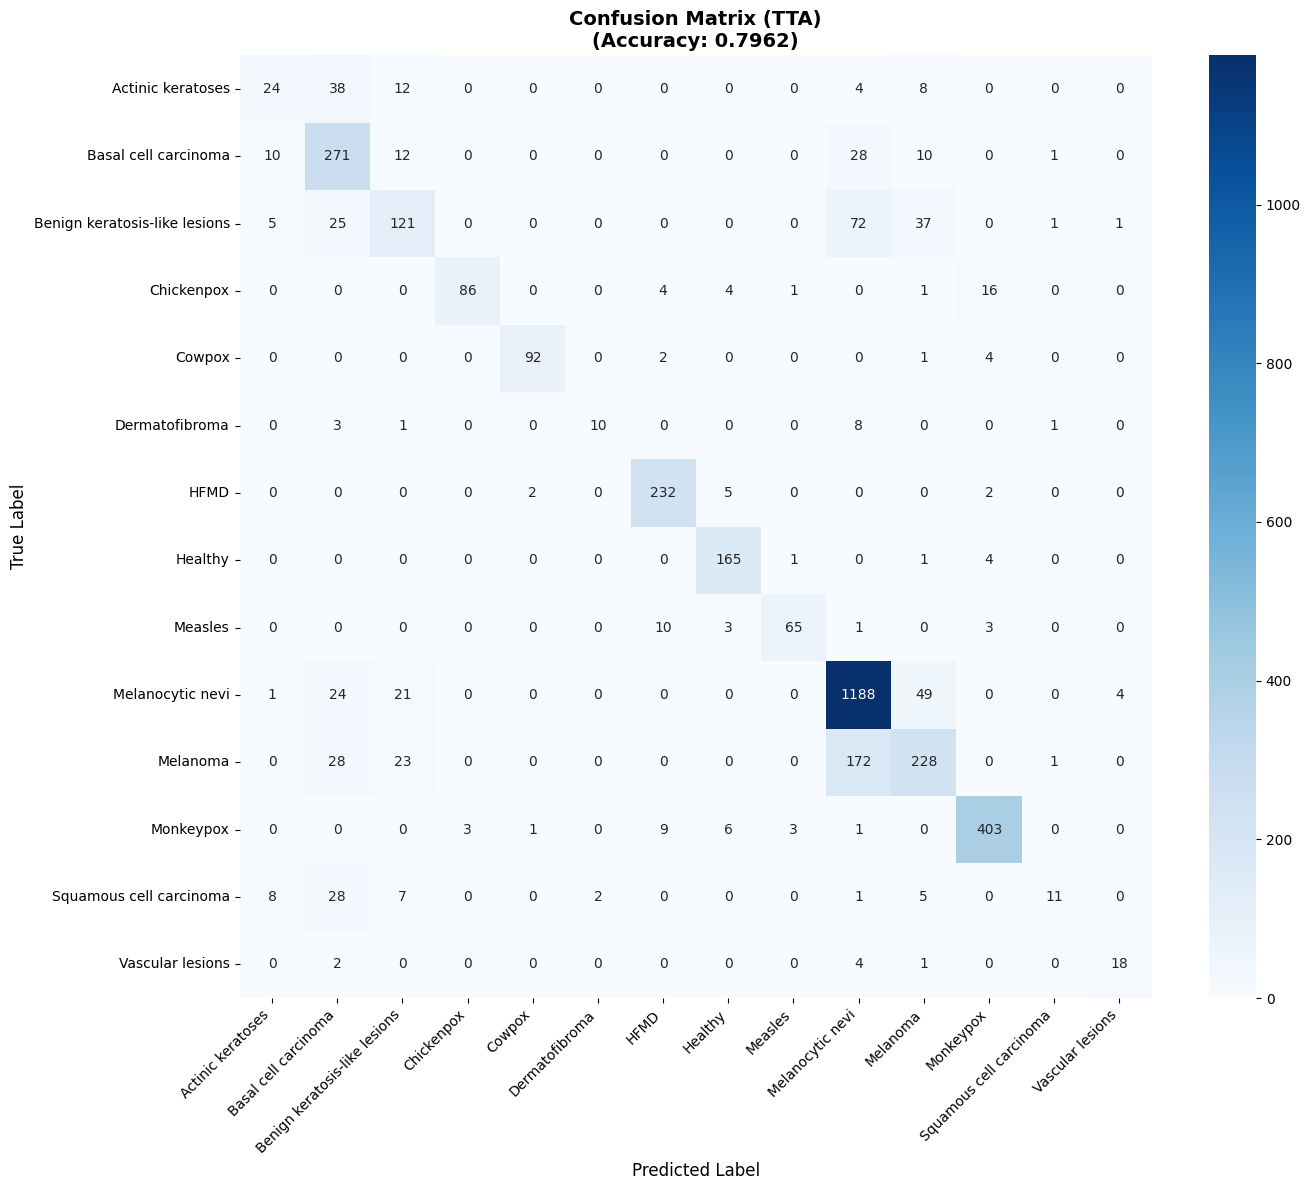


Saved confusion matrix to 'confusion_matrix_tta.png'


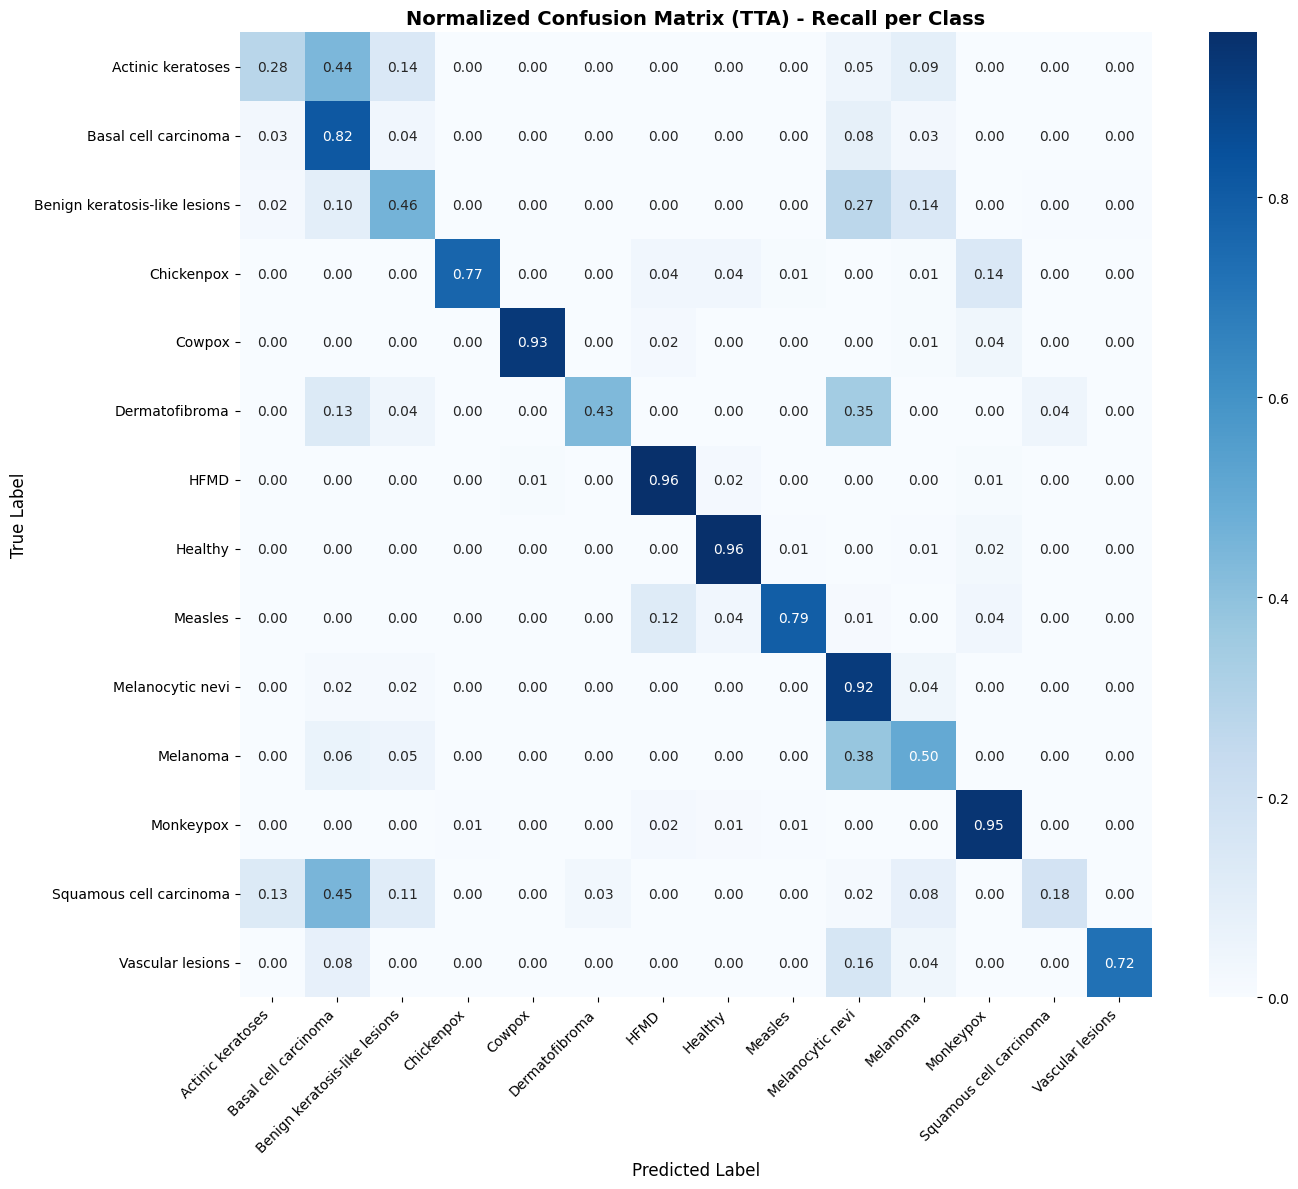

Saved normalized confusion matrix to 'confusion_matrix_normalized_tta.png'


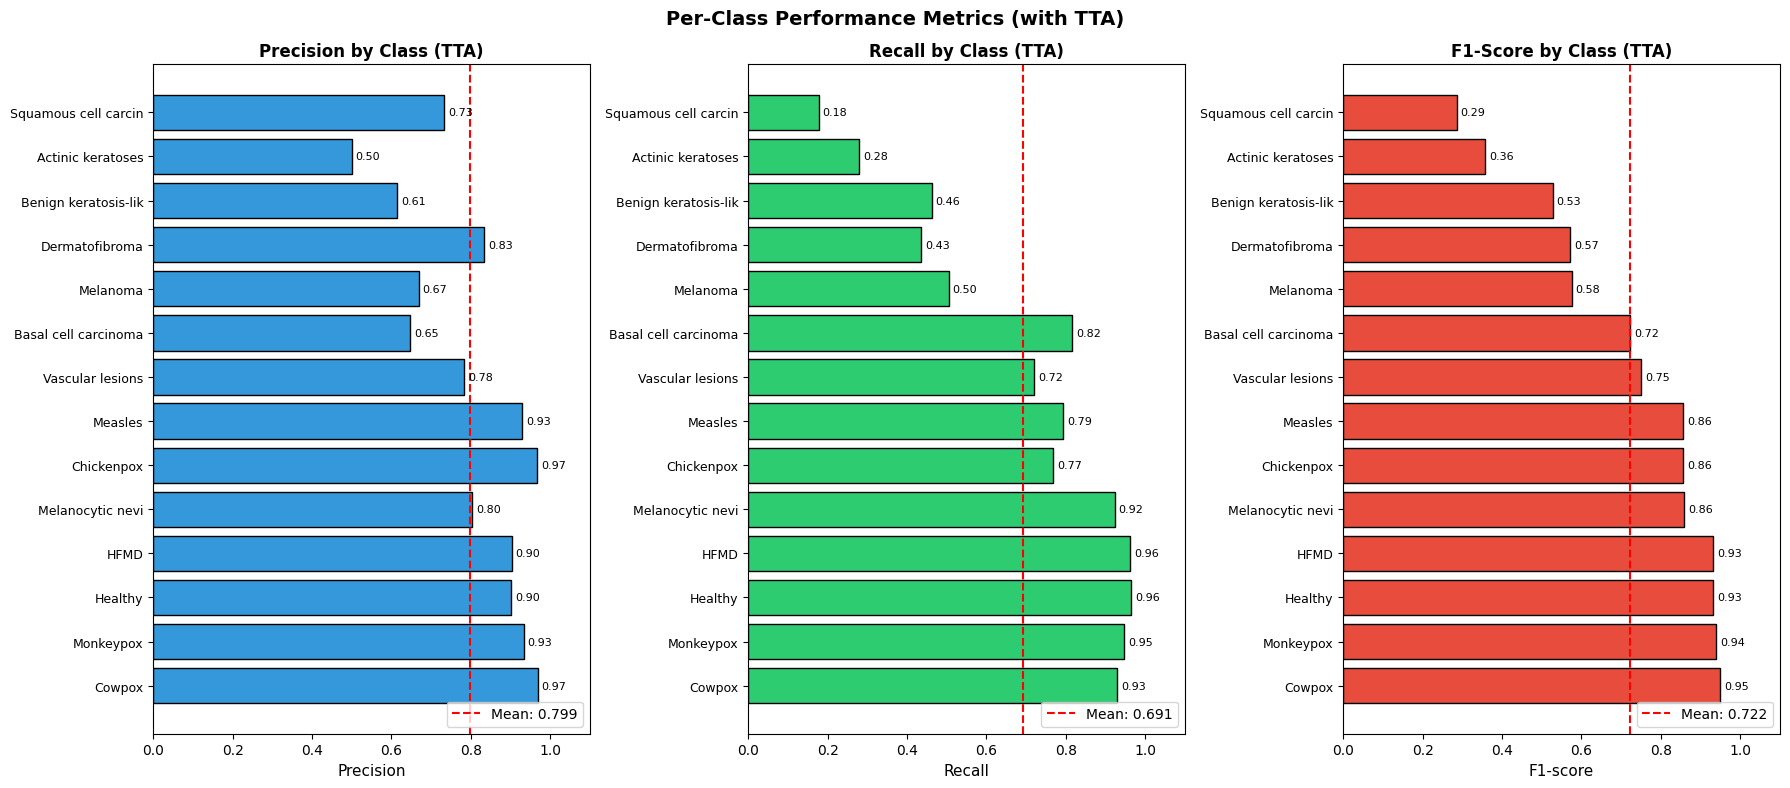

Saved metrics chart to 'metrics_by_class_tta.png'

Saved summary to 'performance_summary_tta.csv'
Saved per-class metrics to 'per_class_metrics_tta.csv'

REPORT COMPLETE!

Generated files:
  - confusion_matrix_tta.png
  - confusion_matrix_normalized_tta.png
  - metrics_by_class_tta.png
  - performance_summary_tta.csv
  - per_class_metrics_tta.csv


In [13]:
# === Full Performance Metrics Report with TTA ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score
)
from tqdm import tqdm
import pandas as pd

def get_predictions_with_tta(model, dataloader, device):
    """
    Get all predictions and labels using Test Time Augmentation (TTA).
    
    TTA Strategy:
    1. Original image
    2. Horizontal flip
    3. Vertical flip
    
    Final prediction = average of softmax probabilities from all augmentations
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    print("Computing predictions with TTA (Original + HFlip + VFlip)...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            
            # 1. Original prediction
            outputs_orig = model(inputs)
            probs_orig = F.softmax(outputs_orig, dim=1)
            
            # 2. Horizontal flip
            inputs_hflip = torch.flip(inputs, dims=[3])
            outputs_hflip = model(inputs_hflip)
            probs_hflip = F.softmax(outputs_hflip, dim=1)
            
            # 3. Vertical flip
            inputs_vflip = torch.flip(inputs, dims=[2])
            outputs_vflip = model(inputs_vflip)
            probs_vflip = F.softmax(outputs_vflip, dim=1)
            
            # Average probabilities (TTA ensemble)
            avg_probs = (probs_orig + probs_hflip + probs_vflip) / 3.0
            
            # Get predictions from averaged probabilities
            _, preds = torch.max(avg_probs, 1)
            
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(avg_probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def generate_full_report_tta(model, dataloader, class_names, device):
    """Generate comprehensive performance metrics report with TTA."""
    
    # Get predictions with TTA
    y_true, y_pred, y_probs = get_predictions_with_tta(model, dataloader, device)
    n_classes = len(class_names)
    
    # 1. OVERALL METRICS
    print("\n" + "="*70)
    print("OVERALL PERFORMANCE METRICS (with TTA)")
    print("="*70)
    
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    top3_acc = top_k_accuracy_score(y_true, y_probs, k=3)
    top5_acc = top_k_accuracy_score(y_true, y_probs, k=5)
    
    # Macro/Micro/Weighted averages
    precision_macro = precision_score(y_true, y_pred, average='macro')
    precision_micro = precision_score(y_true, y_pred, average='micro')
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    
    recall_macro = recall_score(y_true, y_pred, average='macro')
    recall_micro = recall_score(y_true, y_pred, average='micro')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'Metric':<30} {'Value':>12}")
    print("-"*45)
    print(f"{'Accuracy (TTA)':<30} {accuracy:>12.4f}")
    print(f"{'Balanced Accuracy (TTA)':<30} {balanced_acc:>12.4f}")
    print(f"{'Top-3 Accuracy (TTA)':<30} {top3_acc:>12.4f}")
    print(f"{'Top-5 Accuracy (TTA)':<30} {top5_acc:>12.4f}")
    print(f"{'Cohen Kappa':<30} {kappa:>12.4f}")
    print(f"{'Matthews Corr. Coef.':<30} {mcc:>12.4f}")
    print("-"*45)
    print(f"{'Precision (Macro)':<30} {precision_macro:>12.4f}")
    print(f"{'Precision (Micro)':<30} {precision_micro:>12.4f}")
    print(f"{'Precision (Weighted)':<30} {precision_weighted:>12.4f}")
    print("-"*45)
    print(f"{'Recall (Macro)':<30} {recall_macro:>12.4f}")
    print(f"{'Recall (Micro)':<30} {recall_micro:>12.4f}")
    print(f"{'Recall (Weighted)':<30} {recall_weighted:>12.4f}")
    print("-"*45)
    print(f"{'F1-Score (Macro)':<30} {f1_macro:>12.4f}")
    print(f"{'F1-Score (Micro)':<30} {f1_micro:>12.4f}")
    print(f"{'F1-Score (Weighted)':<30} {f1_weighted:>12.4f}")
    print("="*45)
    
    # 2. PER-CLASS METRICS
    print("\n" + "="*90)
    print("PER-CLASS PERFORMANCE METRICS (with TTA)")
    print("="*90)
    
    # Get sklearn classification report as dict
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Create DataFrame for better formatting
    metrics_data = []
    for i, name in enumerate(class_names):
        metrics_data.append({
            'Class': name,
            'Precision': report_dict[name]['precision'],
            'Recall': report_dict[name]['recall'],
            'F1-Score': report_dict[name]['f1-score'],
            'Support': int(report_dict[name]['support'])
        })
    
    df_metrics = pd.DataFrame(metrics_data)
    df_metrics = df_metrics.sort_values('F1-Score', ascending=False)
    
    print(f"\n{'Class':<35} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-"*80)
    for _, row in df_metrics.iterrows():
        print(f"{row['Class']:<35} {row['Precision']:>10.4f} {row['Recall']:>10.4f} {row['F1-Score']:>10.4f} {row['Support']:>10}")
    print("-"*80)
    print(f"{'Macro Avg':<35} {precision_macro:>10.4f} {recall_macro:>10.4f} {f1_macro:>10.4f} {len(y_true):>10}")
    print(f"{'Weighted Avg':<35} {precision_weighted:>10.4f} {recall_weighted:>10.4f} {f1_weighted:>10.4f} {len(y_true):>10}")
    print("="*80)
    
    # 3. CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix (TTA)\n(Accuracy: {accuracy:.4f})', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved confusion matrix to 'confusion_matrix_tta.png'")
    
    # 4. NORMALIZED CONFUSION MATRIX
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Normalized Confusion Matrix (TTA) - Recall per Class', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_normalized_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved normalized confusion matrix to 'confusion_matrix_normalized_tta.png'")
    
    # 5. METRICS BAR CHART
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    
    # Sort by F1-score
    sorted_idx = np.argsort([report_dict[name]['f1-score'] for name in class_names])[::-1]
    sorted_names = [class_names[i] for i in sorted_idx]
    
    metrics_to_plot = ['precision', 'recall', 'f1-score']
    titles = ['Precision by Class (TTA)', 'Recall by Class (TTA)', 'F1-Score by Class (TTA)']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
        values = [report_dict[name][metric] for name in sorted_names]
        short_names = [n[:20] for n in sorted_names]
        
        bars = ax.barh(range(len(sorted_names)), values, color=color, edgecolor='black')
        ax.set_yticks(range(len(sorted_names)))
        ax.set_yticklabels(short_names, fontsize=9)
        ax.set_xlabel(metric.capitalize(), fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlim([0, 1.1])
        ax.axvline(x=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
        ax.legend(loc='lower right')
        
        for bar, val in zip(bars, values):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
    
    plt.suptitle('Per-Class Performance Metrics (with TTA)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('metrics_by_class_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved metrics chart to 'metrics_by_class_tta.png'")
    
    # 6. SUMMARY TABLE (Save to CSV)
    summary_data = {
        'Metric': ['Accuracy (TTA)', 'Balanced Accuracy (TTA)', 'Top-3 Accuracy (TTA)', 'Top-5 Accuracy (TTA)',
                   'Cohen Kappa', 'Matthews Corr. Coef.',
                   'Precision (Macro)', 'Precision (Weighted)',
                   'Recall (Macro)', 'Recall (Weighted)',
                   'F1-Score (Macro)', 'F1-Score (Weighted)'],
        'Value': [accuracy, balanced_acc, top3_acc, top5_acc,
                  kappa, mcc,
                  precision_macro, precision_weighted,
                  recall_macro, recall_weighted,
                  f1_macro, f1_weighted]
    }
    df_summary = pd.DataFrame(summary_data)
    df_summary.to_csv('performance_summary_tta.csv', index=False)
    print("\nSaved summary to 'performance_summary_tta.csv'")
    
    # Save per-class metrics
    df_metrics.to_csv('per_class_metrics_tta.csv', index=False)
    print("Saved per-class metrics to 'per_class_metrics_tta.csv'")
    
    # 7. RETURN RESULTS
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'top3_accuracy': top3_acc,
        'top5_accuracy': top5_acc,
        'kappa': kappa,
        'mcc': mcc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'per_class_report': report_dict,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs
    }


# === RUN ===
print("="*70)
print("FULL PERFORMANCE METRICS REPORT (with TTA)")
print("="*70)

results_tta = generate_full_report_tta(loaded_model, dataloaders['val'], class_names, device)

print("\n" + "="*70)
print("REPORT COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  - confusion_matrix_tta.png")
print("  - confusion_matrix_normalized_tta.png")
print("  - metrics_by_class_tta.png")
print("  - performance_summary_tta.csv")
print("  - per_class_metrics_tta.csv")